In [3]:
import pandas as pd

data = {'x0': [1,1,1,1,1,1,1,1],'x1': [0,0.5,1,1.5,2,2.5,3,3.5], 'y': [2,1.5,1.5,1,1,0,-0.5,-2]}
df = pd.DataFrame(data)

theta0 = 0.5
theta1 = 0.7

print(df)







   x0   x1    y
0   1  0.0  2.0
1   1  0.5  1.5
2   1  1.0  1.5
3   1  1.5  1.0
4   1  2.0  1.0
5   1  2.5  0.0
6   1  3.0 -0.5
7   1  3.5 -2.0


In [2]:
component1 = []
for i in range(df.shape[0]):
    component1.append(df.iloc[i]['x0']*theta0)

component2 = []
for i in range(df.shape[0]):
    component2.append(df.iloc[i]['x1']*theta1)



In [3]:

predictions = []
for i in range(df.shape[0]):
     predictions.append(component1[i] + component2[i])

df['predictions'] = predictions

df['h(x)-y'] = df['predictions'] - df['y']

df


,x0,x1,y,predictions,h(x)-y
0,1,0.0,2.0,0.50,-1.50
1,1,0.5,1.5,0.85,-0.65
2,1,1.0,1.5,1.20,-0.30
3,1,1.5,1.0,1.55,0.55
4,1,2.0,1.0,1.90,0.90
5,1,2.5,0.0,2.25,2.25
6,1,3.0,-0.5,2.60,3.10
7,1,3.5,-2.0,2.95,4.95


In [4]:
import numpy as np

def mse(predictions, targets):
    samples_num = len(predictions)

    accumulated_error = 0
    for prediction, target in zip(predictions, targets):
        accumulated_error += (prediction - target)**2

    mae_error = (1/(samples_num))*accumulated_error

    return mae_error

def mae(predictions, targets):

    samples_num = len(predictions)

    accumulated_error = 0.0
    for prediction, target in zip(predictions, targets):
        accumulated_error += np.abs(prediction - target)

    mae_error = (1/samples_num)* accumulated_error
    
    return mae_error

    


    
    

In [5]:
m = df.shape[0]

targets = df['y']
mae1 = mae(predictions, targets)
mse1 = mse(predictions, targets)

print(mae1)
print(mse1)

print(df)


1.775
5.38125
   x0   x1    y  predictions  h(x)-y
0   1  0.0  2.0         0.50   -1.50
1   1  0.5  1.5         0.85   -0.65
2   1  1.0  1.5         1.20   -0.30
3   1  1.5  1.0         1.55    0.55
4   1  2.0  1.0         1.90    0.90
5   1  2.5  0.0         2.25    2.25
6   1  3.0 -0.5         2.60    3.10
7   1  3.5 -2.0         2.95    4.95


In [6]:
def generatePredictionAndError(df, theta0, theta1):

    df['predictions'] = theta0 * df['x0'] + theta1 * df['x1']

    df['h(x)-y'] = df['predictions'] - df['y']
    
    return df

In [7]:
#Mean Square Error (MSE)

print(df)
originalDF=df

theta0 = 0.5
theta1 = 0.7
learningrate = 0.02

for i in range(100):
    theta0 = theta0 - (learningrate/m)*(df['h(x)-y']*df['x0']).sum()
    theta1 = theta1 - (learningrate/m)*(df['h(x)-y']*df['x1']).sum()

    df = generatePredictionAndError(df, theta0, theta1)

print(theta0)
print(theta1)
print(df)




   x0   x1    y  predictions  h(x)-y
0   1  0.0  2.0         0.50   -1.50
1   1  0.5  1.5         0.85   -0.65
2   1  1.0  1.5         1.20   -0.30
3   1  1.5  1.0         1.55    0.55
4   1  2.0  1.0         1.90    0.90
5   1  2.5  0.0         2.25    2.25
6   1  3.0 -0.5         2.60    3.10
7   1  3.5 -2.0         2.95    4.95
1.0362025374850494
-0.460730190102086
   x0   x1    y  predictions    h(x)-y
0   1  0.0  2.0     1.036203 -0.963797
1   1  0.5  1.5     0.805837 -0.694163
2   1  1.0  1.5     0.575472 -0.924528
3   1  1.5  1.0     0.345107 -0.654893
4   1  2.0  1.0     0.114742 -0.885258
5   1  2.5  0.0    -0.115623 -0.115623
6   1  3.0 -0.5    -0.345988  0.154012
7   1  3.5 -2.0    -0.576353  1.423647


In [8]:
#Mean Absolute Error (MAE)

df = originalDF

theta0 = 0.5
theta1 = 0.7
learningrate = 0.02


for i in range(100):
    
    theta0 = theta0 - (learningrate/m)*((np.sign(df['h(x)-y'])*df['x0']).sum()) #gradient
    theta1 = theta1 - (learningrate/m)*((np.sign(df['h(x)-y'])*df['x1']).sum())
    
    df = generatePredictionAndError(df, theta0, theta1)

print(theta0)
print(theta1)
print(df)

0.9300000000000004
-0.3675000000000004
   x0   x1    y  predictions   h(x)-y
0   1  0.0  2.0      0.93000 -1.07000
1   1  0.5  1.5      0.74625 -0.75375
2   1  1.0  1.5      0.56250 -0.93750
3   1  1.5  1.0      0.37875 -0.62125
4   1  2.0  1.0      0.19500 -0.80500
5   1  2.5  0.0      0.01125  0.01125
6   1  3.0 -0.5     -0.17250  0.32750
7   1  3.5 -2.0     -0.35625  1.64375


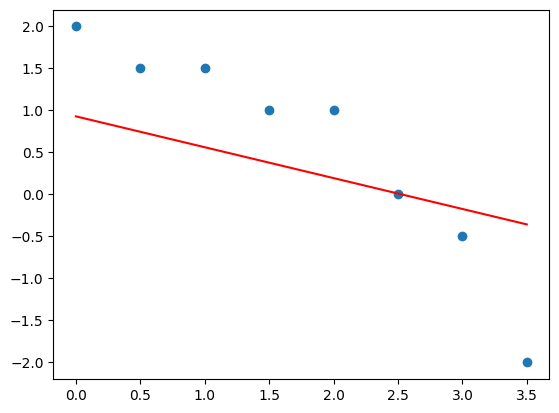

In [9]:
import matplotlib.pyplot as plt

#plt.plot(df['predictions'], df['y'], color = 'red')

plt.scatter(df['x1'], df['y'])
plt.plot(df['x1'], df['predictions'], color = "red")

#QUESTION 2

In [10]:
#part 2

import pandas as pd

data = {'x0': [1,1,1,1,1],'x1': [1,3.5,0.75, 2.5, 1.5], 'x2': [2,1.5,1.25,2,0.5], 'y': [2,2.5,1.5,3.25,1]}
df2 = pd.DataFrame(data)
df2


theta0 = 1
theta1 = 0.5
theta2 = 0.5

print(df2)









   x0    x1    x2     y
0   1  1.00  2.00  2.00
1   1  3.50  1.50  2.50
2   1  0.75  1.25  1.50
3   1  2.50  2.00  3.25
4   1  1.50  0.50  1.00


In [11]:
component1 = []
for i in range(df2.shape[0]):
    component1.append(df2.iloc[i]['x0']*theta0)

component2 = []
for i in range(df2.shape[0]):
    component2.append(df2.iloc[i]['x1']*theta1)

component3 = []
for i in range(df2.shape[0]):
    component3.append(df2.iloc[i]['x2']*theta2)



In [12]:

predictions = []

for i in range(df2.shape[0]):
     predictions.append(component1[i] + component2[i] + component3[i])
print(predictions)

df2['predictions'] = predictions

df2['h(x)-y'] = df2['predictions'] - df2['y']

df2

[2.5, 3.5, 2.0, 3.25, 2.0]


,x0,x1,x2,y,predictions,h(x)-y
0,1,1.00,2.00,2.00,2.50,0.5
1,1,3.50,1.50,2.50,3.50,1.0
2,1,0.75,1.25,1.50,2.00,0.5
3,1,2.50,2.00,3.25,3.25,0.0
4,1,1.50,0.50,1.00,2.00,1.0


In [13]:
m = df2.shape[0]

targets = df2['y']
mae2 = mae(predictions, targets)
mse2 = mse(predictions, targets)

print(mae1)
print(mse1)

print(df2)


1.775
5.38125
   x0    x1    x2     y  predictions  h(x)-y
0   1  1.00  2.00  2.00         2.50     0.5
1   1  3.50  1.50  2.50         3.50     1.0
2   1  0.75  1.25  1.50         2.00     0.5
3   1  2.50  2.00  3.25         3.25     0.0
4   1  1.50  0.50  1.00         2.00     1.0


In [14]:
#Mean Square Error (MSE)

def generatePredictionAndError(df, theta0, theta1, theta2):

    df['predictions'] = theta0 * df['x0'] + theta1 * df['x1'] + theta2 * df['x2']
    

    df['h(x)-y'] = df['predictions'] - df['y']
    
    return df

print(df2)
originalDF2=df2

theta0 = 1
theta1 = 0.5
theta2 = 0.5

learningrate = 0.05

for i in range(5000):
    
    theta0 = theta0 - (learningrate/m)*(df2['h(x)-y']*df2['x0']).sum()
    theta1 = theta1 - (learningrate/m)*(df2['h(x)-y']*df2['x1']).sum()
    theta2 = theta2 - (learningrate/m)*(df2['h(x)-y']*df2['x2']).sum()

    df2 = generatePredictionAndError(df2, theta0, theta1, theta2)

print(theta0)
print(theta1)
print(theta2)
print(df2)




   x0    x1    x2     y  predictions  h(x)-y
0   1  1.00  2.00  2.00         2.50     0.5
1   1  3.50  1.50  2.50         3.50     1.0
2   1  0.75  1.25  1.50         2.00     0.5
3   1  2.50  2.00  3.25         3.25     0.0
4   1  1.50  0.50  1.00         2.00     1.0
-0.12384584433609779
0.3863910075502014
1.0062224002950615
   x0    x1    x2     y  predictions    h(x)-y
0   1  1.00  2.00  2.00     2.274990  0.274990
1   1  3.50  1.50  2.50     2.737856  0.237856
2   1  0.75  1.25  1.50     1.423725 -0.076275
3   1  2.50  2.00  3.25     2.854576 -0.395424
4   1  1.50  0.50  1.00     0.958852 -0.041148


In [15]:
#Mean Absolute Error (MAE)

df2 = originalDF2

theta0 = 0.5
theta1 = 0.7
theta2 = 0.7
learningrate = 0.05

for i in range(10):
    1
    theta0 = theta0 - (learningrate/m)*(np.sign(df2['h(x)-y'])*df2['x0']).sum() #gradient
    theta1 = theta1 - (learningrate/m)*(np.sign(df2['h(x)-y'])*df2['x1']).sum()
    theta2 = theta2 - (learningrate/m)*(np.sign(df2['h(x)-y'])*df2['x2']).sum()
    
    df = generatePredictionAndError(df2, theta0, theta1, theta2)

print(theta0)
print(theta1)
print(theta2)
print(df)

0.0999999999999999
0.3724999999999758
0.9075000000000469
   x0    x1    x2     y  predictions   h(x)-y
0   1  1.00  2.00  2.00      2.28750  0.28750
1   1  3.50  1.50  2.50      2.76500  0.26500
2   1  0.75  1.25  1.50      1.51375  0.01375
3   1  2.50  2.00  3.25      2.84625 -0.40375
4   1  1.50  0.50  1.00      1.11250  0.11250


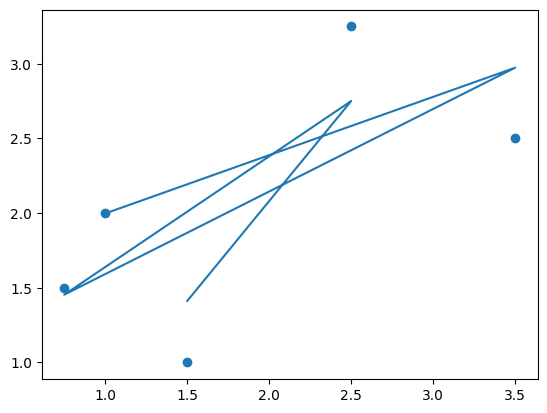

In [17]:
import matplotlib.pyplot as plt

#plt.plot(df['predictions'], df['y'], color = 'red')

plt.scatter(df2['x1'], df2['y'])
plt.plot(df2['x1'], df2['predictions'])

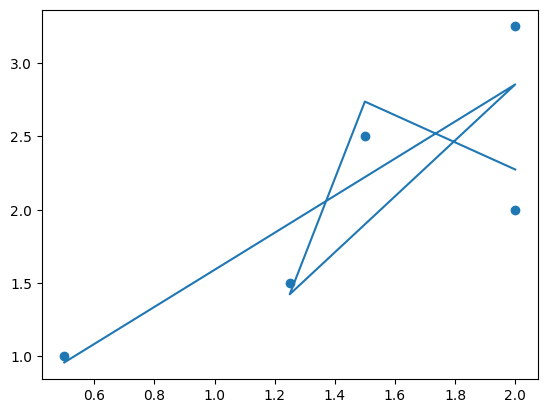

In [15]:
plt.scatter(df2['x2'], df2['y'])
plt.plot(df2['x2'], df2['predictions'])